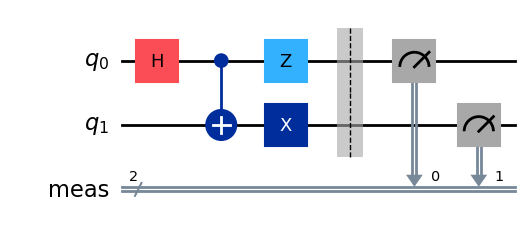

In [1]:
# Import IBM Quantum primitives
from qiskit import QuantumCircuit

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

# Measure state
qc.measure_all()

# Draw circuit
qc.draw("mpl")

In [2]:
# Load IBM Quantum Compute Service
from qiskit_ibm_runtime import QiskitRuntimeService

## Load IBM Quantum Compute Service
# QiskitRuntimeService.save_account(
#    channel="ibm_quantum_platform",
#    token="YOUR_TOKEN_HERE",
#    overwrite=True,
#    set_as_default=True,
# )
# service = QiskitRuntimeService(channel="ibm_quantum_platform")


# Or load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

ibm_kingston


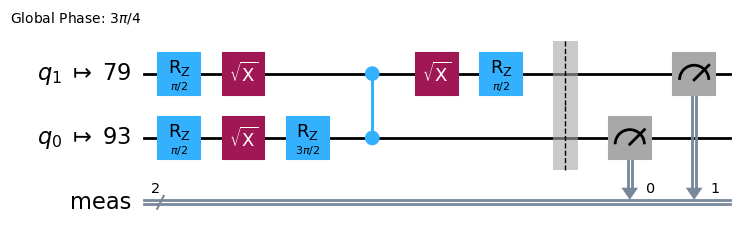

In [3]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

In [4]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

In [5]:
job = sampler.run([qc_isa], shots=100)
# job = sampler_sim.run([qc_isa]) # uncomment if you want to run on a simulator
res = job.result()
counts = res[0].data.meas.get_counts()

counts =  {'10': 44, '01': 52, '00': 3, '11': 1}


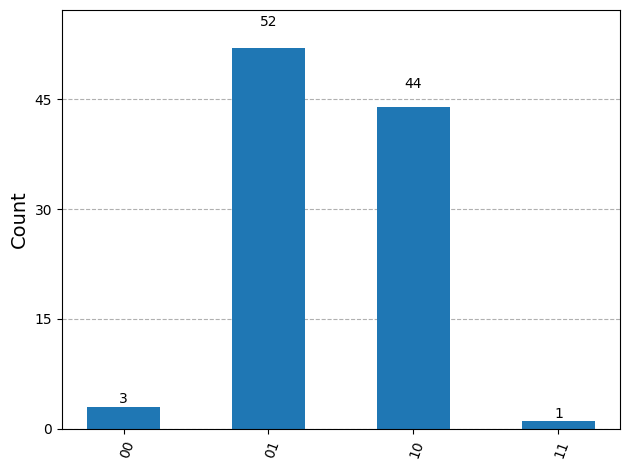

In [6]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)
plot_histogram(counts)

In [7]:
# Import IBM Quantum primitives
from qiskit.quantum_info import SparsePauliOp

# Parameters
J = 1.0  # antiferromagnetic coupling (J>0)
hx = -0.5  # transverse field strength

# 1. Define the Hamiltonian H = J Z1 Z2 + hx (X1 + X2)
obs = SparsePauliOp.from_list([("ZZ", J), ("XI", hx), ("IX", hx)])

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

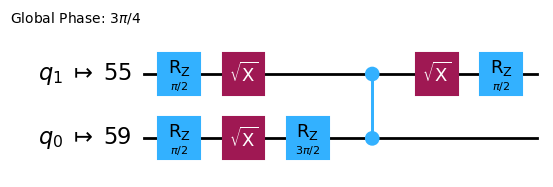

In [8]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)

qc_isa.draw("mpl")

In [9]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [10]:
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()

# Uncomment lines below to run the job on the Aer simulator with noise model from real backend
# job = estimator_sim.run([[qc_isa,obs_isa]])
# res=job.result()

In [11]:
print(res[0].data.evs)

-0.9886359145855085
